# AP 155 Lab Exercise
---
## Exercise 1: Idiomatic Python

_Instructions_: 
- **Report figure (Problem 1):** Plot the 2D wave interference pattern between 2 (or more) coherent sources. Include at least 1 figure.
- **Report discussion (Problem 2):** Write a custom `matrix_multiply()`function using Python list comprehensions without external libraries (do not use `np.dot()` or `@`).
    - (i) For larger matrices, which is preferred, the custom `matrix_multiply()` or the `@` operator... why?
    - (ii) What are the general benefits of writing idiomatic Python?
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Lunas, Bryce Enrico
- _Student No._: 2024-01596
- _Section_: THU-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Problem 1 

![2D Wave Interference Pattern](wave_interference.png)
*Figure 1: 2D wave interference patterns from 2 and 4 coherent sources.*

### Problem 2 

(i) The @ operator (NumPy) is much better for large matrices because it uses fast, pre-compiled C code under the hood. In contrast, our custom function uses pure Python loops, which get extremely slow and memory-heavy when matrices grow large.

(ii) Idiomatic Python makes code shorter, cleaner, and easier to read by using built-in features like list comprehensions instead of long 'for' loops. It also runs faster because Python's built-in shortcuts are internally optimized to run much quicker than standard manual loops.

### Other comments
Questions for Sir:
1. As someone who is tackling/studying coding for the first time, is there a simpler way to teach this course? If yes, how?
2. Are YouTube tutorials effective when it comes to studying this course? Who do you recommend watching? What other sources do you recommend?
3. As seen in the code for Problem 1, how do I center the label for the figure?


---
## Section 2: Code

### Problem 1: 2D Wave interference (Gezerlis Problem 1.15)

Assume that the combined eﬀect of two objects dropped in a water basin can be modelled by:
$$ W(\textbf{r}) = A \sin (k|\textbf{r}-\textbf{r}_0|) + A  \sin (k|\textbf{r}-\textbf{r}_1|). $$ You can think of this as an updated version of Eq. (1.3) in the book, where we are dealing with the linear addition of sinusoidal waves, instead of electric-field contributions. For simplicity, take $A=1$, $k=2\pi/0.3$, $r_0 = (−1, 0)$ , and $r_1 = (1, 0)$. Since we are now faced with a density plot, you should employ, NOT `streamplot()` but, `imshow()` from `Matplotlib`; in each of $x$ and $y$ your plot should extend from $−4$ to $+4$.

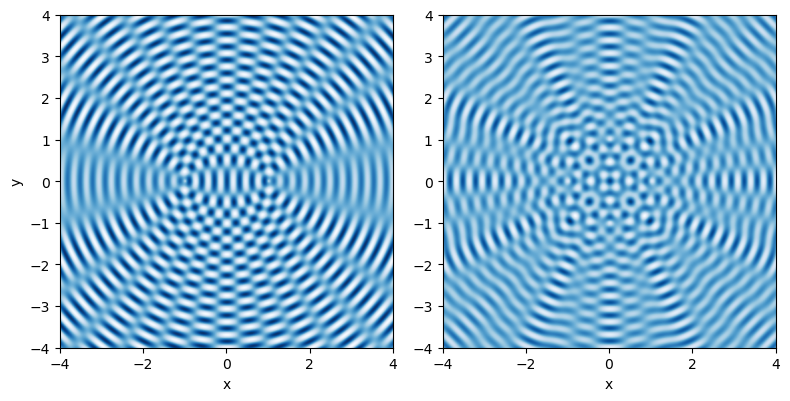

In [12]:
import numpy as np
import matplotlib.pyplot as plt

A = 1.0
k = 2 * np.pi / 0.3

x = np.linspace(-4, 4, 500)
y = np.linspace(-4, 4, 500)
X, Y = np.meshgrid(x, y)

def distance(X, Y, x0, y0):
    return np.sqrt((X - x0)**2 + (Y - y0)**2)

r0_dist = distance(X, Y, -1, 0)
r1_dist = distance(X, Y, 1, 0)
W_2sources = A * np.sin(k * r0_dist) + A * np.sin(k * r1_dist)

sources_4 = [(-1, 0), (1, 0), (0, -1), (0, 1)]
W_4sources = sum(A * np.sin(k * distance(X, Y, sx, sy)) for sx, sy in sources_4)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(
    W_2sources,
    extent=[-4, 4, -4, 4],
    origin='lower',
    cmap='Blues'
)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

axes[1].imshow(
    W_4sources,
    extent=[-4, 4, -4, 4],
    origin='lower',
    cmap='Blues'
)
axes[1].set_xlabel('x')

plt.tight_layout()
plt.savefig('wave_interference.png', dpi=300, bbox_inches='tight')
plt.show()
    

#### Problem 1 code summary

I wrote this script to visualize how waves from two or more point sources overlap by calculating their distance to every point on a 2D grid and adding their sine values together. Using NumPy meshgrids made the math much faster and easier than writing nested loops, while plt.imshow() let me directly map the wave values onto a clean plot from -4 to +4.

---

### Problem 2: Listcomps-maxxing

Import the `random` library (docs: https://docs.python.org/3/library/random.html). We will be using the `random.randint` function to pick random integers.

In [3]:
import random
number = random.randint(1, 9)
number

2

a. Create a function `random_integer_matrix(nrows, ncols)` that generates a matrix in the form of "list-of-lists" whose elements are random integers from $1$ to $9$. Each "sub-list" inside the main list is a row in the matrix.

In [14]:
def random_integer_matrix(nrows, ncols):
    """Generates a matrix of shape (nrows, ncols) containing random integers from 1 to 9."""
    return [[random.randint(1, 9) for _ in range(ncols)] for _ in range(nrows)]

# Test call to print a 3x4 matrix
random_integer_matrix(3, 4)

[[1, 4, 6, 2], [9, 1, 7, 2], [8, 7, 9, 8]]

b. Create a function `scalar_product(list1, list2)` where you multiply each element at the same index in the two lists and sum/accumulate the results.

In [15]:
def scalar_product(list1, list2):
    """Multiplies corresponding elements of two lists and sums the total."""
    return sum(a * b for a, b in zip(list1, list2))

scalar_product([1, 2, 3], [4, 5, 6])

32

In [7]:
# use as many cell blocks as you want (as long as they all are functional)
# include valuable comments (even for trivial functions, a one-liner will do)

c. Create a function `transpose_matrix(orig_matrix)` which returns the transpose of any matrix also in "list-of-lists" form. Do not assume the size of the matrix; figure it out within the function. Double-check that your implementations above work. Create a $3\times4$ random integer matrix, print it out and its transpose. The values and shape between the two should be consistent.

In [18]:
def transpose_matrix(orig_matrix):
    """Returns the transpose of a list-of-lists matrix."""
    return [[row[i] for row in orig_matrix] for i in range(len(orig_matrix[0]))]

mat_3x4 = random_integer_matrix(3, 4)
mat_transposed = transpose_matrix(mat_3x4)

print("Original 3x4 Matrix:", mat_3x4)
print("Transposed Matrix:", mat_transposed)

Original 3x4 Matrix: [[5, 9, 2, 8], [8, 3, 2, 1], [2, 4, 6, 4]]
Transposed Matrix: [[5, 8, 2], [9, 3, 4], [2, 2, 6], [8, 1, 4]]


d. Create a function `matrix_multiply(left_matrix, right_matrix)` which performs the matrix multiplication. Do not assume the matrices follow a specific shape. Here's some tips and strategies:
* Determine how many rows and columns the left and right matrices have. Which numbers should match in order for us to have valid matrix multiplication?
* Iterating the elements of "list-of-lists" gives us the rows, but we need to iterate the columns for the right matrix.
* Use the `transpose_matrix` function, then iteratively apply `scalar_product`.

In [17]:
def matrix_multiply(left_matrix, right_matrix):
    """Multiplies two matrices using transpose_matrix and scalar_product."""
    if len(left_matrix[0]) != len(right_matrix):
        raise ValueError("Inner matrix dimensions must match to multiply.")
    
    right_transposed = transpose_matrix(right_matrix)
    return [[scalar_product(row, col) for col in right_transposed] for row in left_matrix]

# Test d: (3x4) * (4x2)
A = random_integer_matrix(3, 4)
B = random_integer_matrix(4, 2)
print("Result of A x B:", matrix_multiply(A, B))

Result of A x B: [[95, 90], [140, 115], [95, 82]]


#### Problem 2 code summary

This script builds a custom matrix multiplication tool using pure Python list comprehensions to create random grids, flip them with a transpose function, and calculate dot products across rows and columns. I chose list comprehensions instead of traditional nested for loops to keep the functions concise, readable, and Pythonic while directly reusing each helper step.